###Download Datasets

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

100%|██████████| 2.29G/2.29G [00:21<00:00, 113MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


###Necessary Libraries

In [19]:
import os
import cv2
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Input, UpSampling2D, Conv2D, MaxPool2D, Flatten, Dense, Dropout, Activation, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report, confusion_matrix

###Dataset Creation

In [3]:
data_dir = os.path.join(path,"chest_xray/train")

normal_df = pd.DataFrame(columns=['filepaths', 'labels'])
pneumonia_df = pd.DataFrame(columns=['filepaths', 'labels'])

normal_label = 0
pneumonia_label = 1

normal_files = os.listdir(os.path.join(data_dir, "NORMAL"))
pneumonia_files = os.listdir(os.path.join(data_dir, "PNEUMONIA"))

normal_df['filepaths'] = [os.path.join(data_dir, "NORMAL", filename) for filename in normal_files]
normal_df['labels'] = normal_label

pneumonia_df['filepaths'] = [os.path.join(data_dir, "PNEUMONIA", filename) for filename in pneumonia_files]
pneumonia_df['labels'] = pneumonia_label


In [4]:
combined_df = pd.concat([normal_df, pneumonia_df], ignore_index=True)

label_counts = combined_df['labels'].value_counts()
print("\nLabel Counts:")
print(label_counts)


Label Counts:
labels
1    3875
0    1341
Name: count, dtype: int64


###Image Augmentation and Processing

In [5]:
def augment(img):
    datagen = ImageDataGenerator(
        shear_range=0.2,
        zoom_range=0.2,
    )

    img = np.expand_dims(img, 0)
    augmented_images = datagen.flow(img)

    return augmented_images[0]

def process_images(filepaths, image_size=(128, 128)):
    images = []
    for path in filepaths:
        try:
            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, image_size)
            img = img.astype(np.float32) / 255.0

            augmented_img = augment(img)
            augmented_img = np.squeeze(augmented_img, axis=0)

            images.append(augmented_img)
        except Exception as e:
            print(f"Error processing image at path: {path}")
            print(f"Details: {str(e)}")

    return tf.convert_to_tensor(images)

normal_tensor = process_images(normal_df['filepaths'].values)
pneumonia_tensor = process_images(pneumonia_df['filepaths'].values)

print("Normal Tensor Shape:", normal_tensor.shape)
print("Pneumonia Tensor Shape:", pneumonia_tensor.shape)

Normal Tensor Shape: (1341, 128, 128, 3)
Pneumonia Tensor Shape: (3875, 128, 128, 3)


###Data Splitting and Dataset Preparation

In [6]:
# Create label arrays for normal and pneumonia cases
normal_labels = np.zeros(len(normal_tensor), dtype=np.int64)
pneumonia_labels = np.ones(len(pneumonia_tensor), dtype=np.int64)

# Concatenate labels to form a single label array
labels = np.concatenate((normal_labels, pneumonia_labels), axis=0)

# Concatenate processed image tensors
images = np.concatenate((normal_tensor, pneumonia_tensor), axis=0)

# Split the dataset into training and testing sets, ensuring stratified sampling
train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels)

# Create TensorFlow datasets from the split data
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels))

In [7]:
train_dataset_cardinality = train_dataset.cardinality()
print("Number of elements in train_dataset:", train_dataset_cardinality)

test_dataset_cardinality = test_dataset.cardinality()
print("Number of elements in test_dataset:", test_dataset_cardinality)

Number of elements in train_dataset: tf.Tensor(4172, shape=(), dtype=int64)
Number of elements in test_dataset: tf.Tensor(1044, shape=(), dtype=int64)


In [8]:
# Define the batch size for training and evaluation
batch_size = 32

# Shuffle and batch the training dataset
train_data = train_dataset.shuffle(10000).batch(batch_size)

# Batch the test dataset (shuffling is typically not needed for test data)
test_data = test_dataset.batch(batch_size)

In [9]:
for image,label in train_data.take(1):
    print(image.shape)

(32, 128, 128, 3)


###Data Visualization

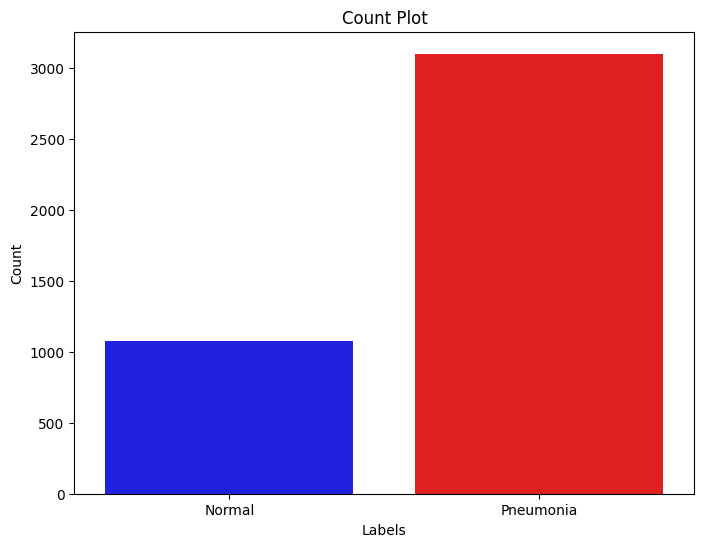

In [10]:
plt.figure(figsize=(8, 6))
sns.countplot(
    x=train_labels,
    hue=train_labels,
    palette={0: 'blue', 1: 'red'},   # Normal = blue, Pneumonia = red
    legend=False
)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Normal', 'Pneumonia'])
plt.title('Count Plot')
plt.show()

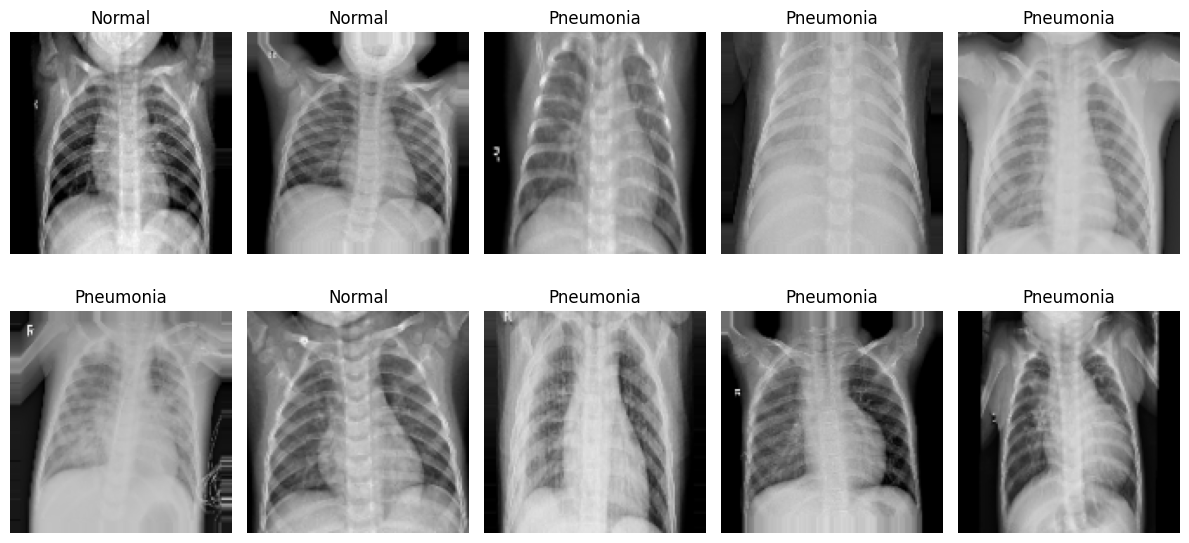

In [11]:
label_names = ['Normal', 'Pneumonia']

def plot_images(images, labels, rows=2, cols=5):
    plt.figure(figsize=(12, 6))
    for i in range(rows * cols):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.title(label_names[labels[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_images(train_images[:10], train_labels[:10])

##Data Oversampling

In [12]:
normal_indices = np.where(train_labels == 0)[0]
pneumonia_indices = np.where(train_labels == 1)[0]

# Count the number of samples for each class
normal_count = len(normal_indices)
pneumonia_count = len(pneumonia_indices)

print(f"Original Normal count: {normal_count}")
print(f"Original Pneumonia count: {pneumonia_count}")

# Calculate the number of additional 'NORMAL' samples required
num_to_oversample = pneumonia_count - normal_count

# Randomly select additional 'NORMAL' samples with replacement
if num_to_oversample > 0:
    oversampled_indices = np.random.choice(normal_indices, size=num_to_oversample, replace=True)

    # Get the oversampled images and labels
    oversampled_normal_images = train_images[oversampled_indices]
    oversampled_normal_labels = train_labels[oversampled_indices]

    # Concatenate the oversampled 'NORMAL' samples with the original training data
    train_images_oversampled = np.concatenate((train_images, oversampled_normal_images), axis=0)
    train_labels_oversampled = np.concatenate((train_labels, oversampled_normal_labels), axis=0)
else:
    train_images_oversampled = train_images
    train_labels_oversampled = train_labels

# Verify the new class distribution
new_normal_count = np.sum(train_labels_oversampled == 0)
new_pneumonia_count = np.sum(train_labels_oversampled == 1)

print(f"\nNew Normal count after oversampling: {new_normal_count}")
print(f"New Pneumonia count after oversampling: {new_pneumonia_count}")

# Update the train_data by creating a new TensorFlow dataset
train_dataset_oversampled = tf.data.Dataset.from_tensor_slices((train_images_oversampled, train_labels_oversampled))
train_data = train_dataset_oversampled.shuffle(10000).batch(batch_size)

print(f"Number of elements in oversampled train_dataset: {train_dataset_oversampled.cardinality()}")

Original Normal count: 1073
Original Pneumonia count: 3099

New Normal count after oversampling: 3099
New Pneumonia count after oversampling: 3099
Number of elements in oversampled train_dataset: 6198


##Transfer Learning(TL)

###Mobilenet based Model

In [15]:
base_model = MobileNetV2(weights= 'imagenet', include_top=False, input_shape= (128,128,3))
# Freeze the layers of the base model so they are not updated during training
base_model.trainable = False

x = base_model.output
# Flatten the output from the convolutional base to feed into a dense layer
x = Flatten()(x)
# Add a dense layer with ReLU activation for feature learning
x = Dense(256, activation= 'relu')(x)
# Add dropout for regularization to prevent overfitting
x = Dropout(0.2)(x)
# Add a final dense layer with sigmoid activation for binary classification (Pneumonia or Normal)
predictions = Dense(1, activation= 'sigmoid')(x)
# Create the full model by connecting the base model's input to the new prediction layers
model = Model(inputs = base_model.input, outputs = predictions)
# Compile the model with Adam optimizer, binary crossentropy loss (for binary classification), and accuracy metric
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Print a summary of the model architecture
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 7,501,377 (28.62 MB)

 Trainable params: 5,243,393 (20.00 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

###Model Training

In [16]:
# Train the model using the oversampled training data and validate on the test data
# epochs=10 means the model will iterate over the entire dataset 10 times
history = model.fit(train_data, epochs=10, validation_data= test_data)

Epoch 1/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 102s 489ms/step - accuracy: 0.9263 - loss: 0.3375 - val_accuracy: 0.9646 - val_loss: 0.1034
Epoch 2/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 87s 449ms/step - accuracy: 0.9739 - loss: 0.0784 - val_accuracy: 0.9588 - val_loss: 0.1067
Epoch 3/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 86s 446ms/step - accuracy: 0.9861 - loss: 0.0465 - val_accuracy: 0.9655 - val_loss: 0.1050
Epoch 4/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 87s 449ms/step - accuracy: 0.9892 - loss: 0.0290 - val_accuracy: 0.9598 - val_loss: 0.1185
Epoch 5/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 143s 456ms/step - accuracy: 0.9926 - loss: 0.0226 - val_accuracy: 0.9617 - val_loss: 0.1270
Epoch 6/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 142s 454ms/step - accuracy: 0.9945 - loss: 0.0178 - val_accuracy: 0.9607 - val_loss: 0.1343
Epoch 7/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 86s 443ms/step - accuracy: 0.9903 - loss: 0.0275 - val_accuracy: 0.9617 - val_loss: 0.1563
Epoch 8/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 86s 445ms/step - accuracy: 0.9932 - loss

###Training and Validation Metrics Visualization

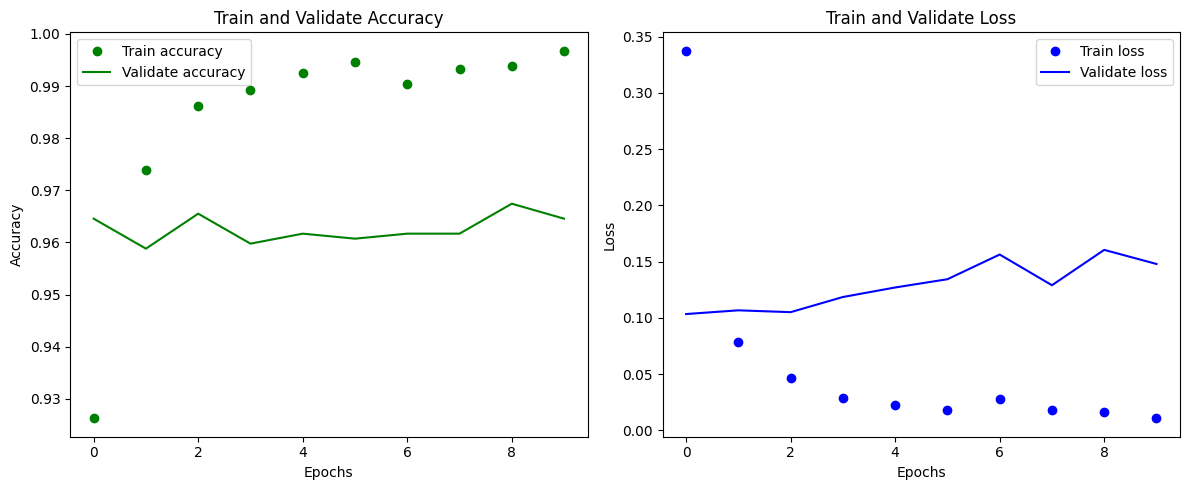

In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, 'go', label='Train accuracy')
plt.plot(val_acc, 'g', label='Validate accuracy')
plt.title('Train and Validate Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, 'bo', label='Train loss')
plt.plot(val_loss, 'b', label='Validate loss')
plt.title('Train and Validate Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

###Model Evaluation

In [18]:
probabilities = model.predict(test_data)
predicted_classes = (probabilities > 0.5).astype(int)

33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 389ms/step


In [20]:
report = classification_report(test_labels, predicted_classes)
print(report)

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       268
           1       0.98      0.97      0.98       776

    accuracy                           0.96      1044
   macro avg       0.95      0.96      0.95      1044
weighted avg       0.97      0.96      0.96      1044



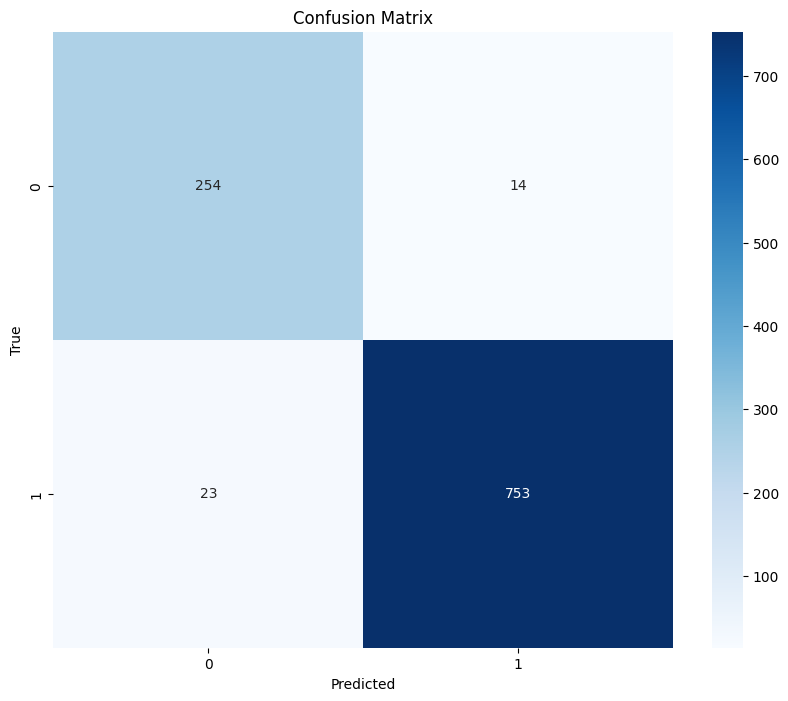

In [21]:
conf_matrix = confusion_matrix(test_labels, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [22]:
results = model.evaluate(test_data, verbose=True)

loss = round(results[0], 2)
accuracy = round(results[1] * 100, 2)

print(f'Test results - Loss: {loss} - Accuracy: {accuracy}%')

33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 340ms/step - accuracy: 0.9646 - loss: 0.1479
Test results - Loss: 0.15 - Accuracy: 96.46%


###Prediction using Mobilnet based Model

In [24]:
def predict_pneumonia_or_normal(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(128, 128))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    predictions = model.predict(img_preprocessed)

    if predictions[0] > 0.5:
        return '\nPrediction: Pneumonia (Class 1)\n'
    else:
        return '\nPrediction: Normal (Class 0)\n'

test_data_dir = os.path.join(path, "chest_xray/test")

img_paths = [
    os.path.join(test_data_dir, 'PNEUMONIA/person101_bacteria_484.jpeg'),
    os.path.join(test_data_dir, 'PNEUMONIA/person102_bacteria_487.jpeg'),
    os.path.join(test_data_dir, 'NORMAL/IM-0005-0001.jpeg'),
    os.path.join(test_data_dir, 'NORMAL/IM-0015-0001.jpeg')
]

for img_path in img_paths:
    prediction = predict_pneumonia_or_normal(img_path)
    print(f'For image {img_path}, {prediction}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
For image /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/test/PNEUMONIA/person101_bacteria_484.jpeg, 
Prediction: Pneumonia (Class 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
For image /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/test/PNEUMONIA/person102_bacteria_487.jpeg, 
Prediction: Pneumonia (Class 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
For image /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/test/NORMAL/IM-0005-0001.jpeg, 
Prediction: Normal (Class 0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
For image /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/test/NORMAL/IM-0015-0001.jpeg, 
Prediction: Normal (Class 0)

